# Analisis estadistico de benchmarks

Este notebook carga automaticamente los `results/runs.csv` del suite de benchmarks, calcula estadisticas descriptivas por algoritmo y problema, ejecuta Friedman cuando hay seeds pareadas suficientes, lanza post-hoc si aparecen diferencias significativas y genera tablas y graficos.

El flujo esta pensado para ejecutarse desde la carpeta `benchmark_suite/`. Si aun no existen resultados, primero hay que ejecutar las orquestaciones para generar los CSVs.

In [1]:
# Dependencias recomendadas para este notebook.
# Descomenta la siguiente linea si el kernel no tiene las librerias instaladas.
# %pip install -r requirements-analysis.txt matplotlib seaborn

In [2]:
from __future__ import annotations

import math
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats as scipy_stats

try:
    import scikit_posthocs as sp
except ImportError:
    sp = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import seaborn as sns
except ImportError:
    sns = None

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 200)
pd.options.display.float_format = lambda value: f'{value:,.4f}' if pd.notna(value) else ''

BENCHMARK_SUITE_ROOT = Path.cwd().resolve()
RESULT_CANDIDATES = ('results/runs.csv', 'results/raw/runs.csv')
ALPHA = 0.05

display(Markdown(f'**Benchmark suite root:** `{BENCHMARK_SUITE_ROOT}`'))

**Benchmark suite root:** `/home/drlk/roma/benchmark_suite`

In [3]:
def discover_runs_csvs(root: Path) -> list[dict]:
    records = []
    for child in sorted(root.iterdir()):
        if not child.is_dir() or child.name.startswith('__'):
            continue
        for relative_path in RESULT_CANDIDATES:
            candidate = child / relative_path
            if candidate.exists():
                records.append({
                    'benchmark_dir': child.name,
                    'csv_path': candidate,
                    'source': relative_path,
                })
                break
    return records


def coerce_bool(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return value
    lowered = str(value).strip().lower()
    if lowered in {'true', '1', 'yes', 'si'}:
        return True
    if lowered in {'false', '0', 'no'}:
        return False
    return np.nan


def normalize_runs(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()
    for column in [
        'benchmark_id', 'problem', 'instance_id', 'algorithm', 'objective_sense',
        'status', 'budget_type', 'final_fitness', 'best_fitness', 'wall_time_ms',
        'cpu_time_ms', 'seed', 'budget_value', 'success', 'evaluations', 'dimension'
    ]:
        if column not in df.columns:
            df[column] = None

    if 'benchmark_id' not in raw_df.columns and 'benchmark_dir' in raw_df.columns:
        df['benchmark_id'] = raw_df['benchmark_dir']

    df['final_fitness'] = df['final_fitness'].fillna(df['best_fitness'])
    df['objective_sense'] = df['objective_sense'].fillna('min')
    df['success'] = df['success'].map(coerce_bool)
    df['success'] = df['success'].where(df['success'].notna(), df['status'] == 'ok')

    for column in [
        'dimension', 'seed', 'budget_value', 'final_fitness', 'best_fitness',
        'wall_time_ms', 'cpu_time_ms', 'evaluations', 'returncode'
    ]:
        df[column] = pd.to_numeric(df[column], errors='coerce')

    df['instance_key'] = df.apply(
        lambda row: f"{row['benchmark_id']}::{row['instance_id']}",
        axis=1,
    )
    return df


def load_suite_runs(root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    csv_records = discover_runs_csvs(root)
    if not csv_records:
        return pd.DataFrame(), pd.DataFrame(columns=['benchmark_dir', 'csv_path', 'source'])

    frames = []
    for record in csv_records:
        frame = pd.read_csv(record['csv_path'])
        frame['benchmark_dir'] = record['benchmark_dir']
        frame['csv_path'] = str(record['csv_path'].relative_to(root))
        frame['csv_source'] = record['source']
        frames.append(frame)

    combined = pd.concat(frames, ignore_index=True, sort=False)
    return normalize_runs(combined), pd.DataFrame(csv_records)


def safe_mean(values: pd.Series) -> float:
    clean = values.dropna().astype(float)
    return float(clean.mean()) if not clean.empty else math.nan


def safe_median(values: pd.Series) -> float:
    clean = values.dropna().astype(float)
    return float(clean.median()) if not clean.empty else math.nan


def safe_std(values: pd.Series) -> float:
    clean = values.dropna().astype(float)
    return float(clean.std(ddof=0)) if not clean.empty else math.nan


def holm_adjust(pairwise_df: pd.DataFrame, p_column: str = 'p_value') -> pd.DataFrame:
    if pairwise_df.empty:
        return pairwise_df.copy()

    adjusted = pairwise_df.copy()
    adjusted['p_holm'] = np.nan
    valid = adjusted[pd.notna(adjusted[p_column])].sort_values(p_column).copy()
    total = len(valid)
    running_max = 0.0

    for index, row in enumerate(valid.itertuples()):
        corrected = min(1.0, max(running_max, (total - index) * getattr(row, p_column)))
        adjusted.loc[row.Index, 'p_holm'] = corrected
        running_max = corrected

    return adjusted


def build_descriptive_table(problem_df: pd.DataFrame) -> pd.DataFrame:
    ok_df = problem_df[problem_df['status'] == 'ok'].copy()
    rows = []
    for algorithm, group in ok_df.groupby('algorithm', sort=True):
        rows.append({
            'algorithm': algorithm,
            'run_count': int(len(group)),
            'seed_count': int(group['seed'].dropna().nunique()),
            'success_rate': float(group['success'].astype(float).mean()) if len(group) else math.nan,
            'mean_fitness': safe_mean(group['final_fitness']),
            'median_fitness': safe_median(group['final_fitness']),
            'std_fitness': safe_std(group['final_fitness']),
            'best_fitness': float(group['final_fitness'].min()) if group['objective_sense'].iloc[0] == 'min' else float(group['final_fitness'].max()),
            'mean_wall_time_ms': safe_mean(group['wall_time_ms']),
            'median_wall_time_ms': safe_median(group['wall_time_ms']),
            'total_wall_time_ms': float(group['wall_time_ms'].dropna().sum()) if group['wall_time_ms'].dropna().size else math.nan,
            'mean_cpu_time_ms': safe_mean(group['cpu_time_ms']),
            'median_cpu_time_ms': safe_median(group['cpu_time_ms']),
            'total_cpu_time_ms': float(group['cpu_time_ms'].dropna().sum()) if group['cpu_time_ms'].dropna().size else math.nan,
        })
    return pd.DataFrame(rows).sort_values('algorithm').reset_index(drop=True)


def run_problem_friedman(problem_df: pd.DataFrame, metric: str = 'final_fitness', alpha: float = ALPHA) -> dict:
    ok_df = problem_df[problem_df['status'] == 'ok'].copy()
    objective_sense = ok_df['objective_sense'].iloc[0] if not ok_df.empty else 'min'
    algorithms = sorted(ok_df['algorithm'].dropna().unique().tolist())

    if ok_df.empty:
        return {'status': 'skipped', 'reason': 'No hay ejecuciones correctas.', 'friedman': pd.DataFrame(), 'ranks': pd.DataFrame(), 'wilcoxon': pd.DataFrame(), 'nemenyi': pd.DataFrame(), 'wide': pd.DataFrame()}

    metric_df = ok_df[['seed', 'algorithm', metric]].dropna(subset=['seed', metric])
    wide = metric_df.pivot_table(index='seed', columns='algorithm', values=metric, aggfunc='first').reindex(columns=algorithms)
    wide = wide.dropna(axis=0, how='any')

    if len(algorithms) < 3:
        reason = 'Friedman requiere al menos 3 algoritmos.'
        friedman_df = pd.DataFrame([{'metric': metric, 'status': 'skipped', 'reason': reason, 'paired_seeds': int(len(wide)), 'algorithm_count': len(algorithms), 'statistic': math.nan, 'p_value': math.nan}])
        return {'status': 'skipped', 'reason': reason, 'friedman': friedman_df, 'ranks': pd.DataFrame(), 'wilcoxon': pd.DataFrame(), 'nemenyi': pd.DataFrame(), 'wide': wide}

    if len(wide) < 2:
        reason = 'Friedman requiere al menos 2 seeds compartidas por todos los algoritmos.'
        friedman_df = pd.DataFrame([{'metric': metric, 'status': 'skipped', 'reason': reason, 'paired_seeds': int(len(wide)), 'algorithm_count': len(algorithms), 'statistic': math.nan, 'p_value': math.nan}])
        return {'status': 'skipped', 'reason': reason, 'friedman': friedman_df, 'ranks': pd.DataFrame(), 'wilcoxon': pd.DataFrame(), 'nemenyi': pd.DataFrame(), 'wide': wide}

    samples = [wide[algorithm].to_numpy(dtype=float) for algorithm in algorithms]
    statistic, p_value = scipy_stats.friedmanchisquare(*samples)
    friedman_df = pd.DataFrame([{
        'metric': metric,
        'status': 'ok',
        'reason': None,
        'paired_seeds': int(len(wide)),
        'algorithm_count': len(algorithms),
        'statistic': float(statistic),
        'p_value': float(p_value),
    }])

    ranks = wide.rank(axis=1, method='average', ascending=(objective_sense == 'min')).mean(axis=0)
    ranks_df = ranks.rename('average_rank').reset_index().rename(columns={'index': 'algorithm'}).sort_values('average_rank').reset_index(drop=True)
    ranks_df['metric'] = metric
    ranks_df['paired_seeds'] = int(len(wide))

    wilcoxon_rows = []
    nemenyi_df = pd.DataFrame()
    if p_value < alpha:
        for left, right in combinations(algorithms, 2):
            pair = wide[[left, right]].dropna()
            if len(pair) < 2:
                wilcoxon_rows.append({
                    'metric': metric,
                    'algorithm_a': left,
                    'algorithm_b': right,
                    'paired_seeds': int(len(pair)),
                    'statistic': math.nan,
                    'p_value': math.nan,
                    'reason': 'Wilcoxon requiere al menos 2 seeds pareadas.',
                })
                continue

            values_left = pair[left].to_numpy(dtype=float)
            values_right = pair[right].to_numpy(dtype=float)
            if np.allclose(values_left - values_right, 0.0, rtol=1e-12, atol=1e-12):
                wilcoxon_rows.append({
                    'metric': metric,
                    'algorithm_a': left,
                    'algorithm_b': right,
                    'paired_seeds': int(len(pair)),
                    'statistic': math.nan,
                    'p_value': math.nan,
                    'reason': 'Todas las diferencias pareadas son cero.',
                })
                continue

            wilcoxon_stat, wilcoxon_p = scipy_stats.wilcoxon(values_left, values_right, zero_method='wilcox')
            wilcoxon_rows.append({
                'metric': metric,
                'algorithm_a': left,
                'algorithm_b': right,
                'paired_seeds': int(len(pair)),
                'statistic': float(wilcoxon_stat),
                'p_value': float(wilcoxon_p),
                'reason': None,
            })

        wilcoxon_df = holm_adjust(pd.DataFrame(wilcoxon_rows))

        if sp is not None:
            nemenyi_matrix = sp.posthoc_nemenyi_friedman(wide[algorithms])
            nemenyi_df = (
                nemenyi_matrix
                .stack()
                .rename('adjusted_p_value')
                .reset_index()
                .rename(columns={'level_0': 'algorithm_a', 'level_1': 'algorithm_b'})
            )
            nemenyi_df['metric'] = metric
    else:
        wilcoxon_df = pd.DataFrame()

    return {
        'status': 'ok',
        'reason': None,
        'friedman': friedman_df,
        'ranks': ranks_df,
        'wilcoxon': wilcoxon_df,
        'nemenyi': nemenyi_df,
        'wide': wide,
    }


def analyze_suite(runs_df: pd.DataFrame) -> dict:
    if runs_df.empty:
        return {}

    results = {}
    for benchmark_id, problem_df in runs_df.groupby('benchmark_id', sort=True):
        results[benchmark_id] = {
            'descriptive': build_descriptive_table(problem_df),
            'fitness_test': run_problem_friedman(problem_df, metric='final_fitness'),
            'wall_time_test': run_problem_friedman(problem_df, metric='wall_time_ms'),
        }
    return results

In [4]:
runs_df, discovered_csvs = load_suite_runs(BENCHMARK_SUITE_ROOT)
analysis = analyze_suite(runs_df)

if discovered_csvs.empty:
    display(Markdown('**No se han encontrado `results/runs.csv` en `benchmark_suite/`.**'))
else:
    display(Markdown('## CSVs detectados'))
    display(discovered_csvs.assign(csv_path=lambda df: df['csv_path'].astype(str)))
    overview = (
        runs_df.groupby(['benchmark_id', 'algorithm', 'status'], dropna=False)
        .size()
        .rename('rows')
        .reset_index()
        .sort_values(['benchmark_id', 'algorithm', 'status'])
    )
    display(Markdown('## Resumen de ejecuciones'))
    display(overview)

## CSVs detectados

,benchmark_dir,csv_path,source
0,rastrigin_hill_climbing,/home/drlk/roma/benchmark_suite/rastrigin_hill...,results/runs.csv


## Resumen de ejecuciones

,benchmark_id,algorithm,status,rows
0,rastrigin_hill_climbing,deap,ok,50
1,rastrigin_hill_climbing,jmetal_java,ok,50
2,rastrigin_hill_climbing,jmetalpy,ok,50
3,rastrigin_hill_climbing,mealpy,ok,50
4,rastrigin_hill_climbing,pagmo2_cpp,ok,50
5,rastrigin_hill_climbing,roma,ok,50


In [6]:
if not analysis:
    display(Markdown('No hay datos cargados para calcular estadisticas descriptivas.'))
else:
    for benchmark_id, payload in analysis.items():
        display(Markdown(f'## Descriptivos: {benchmark_id}'))
        descriptive = payload['descriptive']
        if descriptive.empty:
            display(Markdown('Sin ejecuciones correctas para este benchmark.'))
            continue
        display(
            descriptive.style.format({
                'success_rate': '{:.2%}',
                'mean_fitness': '{:.4f}',
                'median_fitness': '{:.4f}',
                'std_fitness': '{:.4f}',
                'best_fitness': '{:.4f}',
                'mean_wall_time_ms': '{:.2f}',
                'median_wall_time_ms': '{:.2f}',
                'total_wall_time_ms': '{:.2f}',
                'mean_cpu_time_ms': '{:.2f}',
                'median_cpu_time_ms': '{:.2f}',
                'total_cpu_time_ms': '{:.2f}',
            })
        )

## Descriptivos: rastrigin_hill_climbing

,algorithm,run_count,seed_count,success_rate,mean_fitness,median_fitness,std_fitness,best_fitness,mean_wall_time_ms,median_wall_time_ms,total_wall_time_ms,mean_cpu_time_ms,median_cpu_time_ms,total_cpu_time_ms
0,deap,50,50,100.00%,836.6267,842.8651,71.0830,656.3271,281.79,281.39,14089.57,nan,nan,nan
1,jmetal_java,50,50,100.00%,708.7861,710.7929,63.3832,555.0853,70.19,69.48,3509.30,66.22,65.01,3310.88
2,jmetalpy,50,50,100.00%,701.9362,706.2288,57.5705,559.2057,343.92,341.84,17195.82,nan,nan,nan
3,mealpy,50,50,100.00%,955.6883,945.2226,72.6923,825.9898,272.03,263.46,13601.45,nan,nan,nan
4,pagmo2_cpp,50,50,100.00%,968.5648,974.3128,74.1816,845.2973,4.84,4.73,241.83,4.74,4.61,237.11
5,roma,50,50,100.00%,703.4857,695.0865,57.9933,613.6133,30.01,29.40,1500.60,28.73,28.04,1436.73


In [7]:
def display_inference_block(title: str, result: dict):
    display(Markdown(f'### {title}'))
    display(result['friedman'])
    if result['friedman'].empty:
        return

    if not result['ranks'].empty:
        display(Markdown('**Rangos medios**'))
        display(result['ranks'])

    p_value = result['friedman']['p_value'].iloc[0] if 'p_value' in result['friedman'].columns and not result['friedman'].empty else math.nan
    if pd.notna(p_value) and p_value < ALPHA:
        display(Markdown(f'**Post-hoc activado** porque $p < {ALPHA}$.'))
        if not result['wilcoxon'].empty:
            display(Markdown('**Wilcoxon pareado con correccion de Holm**'))
            display(result['wilcoxon'].sort_values(['p_holm', 'p_value'], na_position='last'))
        if not result['nemenyi'].empty:
            display(Markdown('**Nemenyi**'))
            display(result['nemenyi'])
        elif sp is None:
            display(Markdown('`scikit-posthocs` no esta disponible; se omite Nemenyi.'))
    else:
        display(Markdown('No hay evidencia suficiente para activar post-hoc.'))


if not analysis:
    display(Markdown('No hay datos cargados para inferencia estadistica.'))
else:
    for benchmark_id, payload in analysis.items():
        display(Markdown(f'## Friedman y post-hoc: {benchmark_id}'))
        display_inference_block('Fitness final', payload['fitness_test'])
        display_inference_block('Tiempo de ejecucion (wall_time_ms)', payload['wall_time_test'])

## Friedman y post-hoc: rastrigin_hill_climbing

### Fitness final

,metric,status,reason,paired_seeds,algorithm_count,statistic,p_value
0,final_fitness,ok,None,50,6,197.5657,0.0000


**Rangos medios**

,algorithm,average_rank,metric,paired_seeds
0,jmetalpy,2.0200,final_fitness,50
1,jmetal_java,2.0800,final_fitness,50
2,roma,2.0800,final_fitness,50
3,deap,3.9800,final_fitness,50
4,mealpy,5.3800,final_fitness,50
5,pagmo2_cpp,5.4600,final_fitness,50


...

**Post-hoc activado** porque $p < 0.05$.

**Wilcoxon pareado con correccion de Holm**

,metric,algorithm_a,algorithm_b,paired_seeds,statistic,p_value,reason,p_holm
0,wall_time_ms,deap,jmetal_java,50,0.0000,0.0000,None,0.0000
1,wall_time_ms,deap,jmetalpy,50,0.0000,0.0000,None,0.0000
3,wall_time_ms,deap,pagmo2_cpp,50,0.0000,0.0000,None,0.0000
4,wall_time_ms,deap,roma,50,0.0000,0.0000,None,0.0000
5,wall_time_ms,jmetal_java,jmetalpy,50,0.0000,0.0000,None,0.0000
6,wall_time_ms,jmetal_java,mealpy,50,0.0000,0.0000,None,0.0000
7,wall_time_ms,jmetal_java,pagmo2_cpp,50,0.0000,0.0000,None,0.0000
8,wall_time_ms,jmetal_java,roma,50,0.0000,0.0000,None,0.0000
9,wall_time_ms,jmetalpy,mealpy,50,0.0000,0.0000,None,0.0000
10,wall_time_ms,jmetalpy,pagmo2_cpp,50,0.0000,0.0000,None,0.0000


**Nemenyi**

,algorithm_a,algorithm_b,adjusted_p_value,metric
0,deap,deap,1.0000,wall_time_ms
1,deap,jmetal_java,0.0001,wall_time_ms
2,deap,jmetalpy,0.0068,wall_time_ms
3,deap,mealpy,0.8937,wall_time_ms
4,deap,pagmo2_cpp,0.0000,wall_time_ms
5,deap,roma,0.0000,wall_time_ms
6,jmetal_java,deap,0.0001,wall_time_ms
7,jmetal_java,jmetal_java,1.0000,wall_time_ms
8,jmetal_java,jmetalpy,0.0000,wall_time_ms
9,jmetal_java,mealpy,0.0068,wall_time_ms


## Graficos: rastrigin_hill_climbing

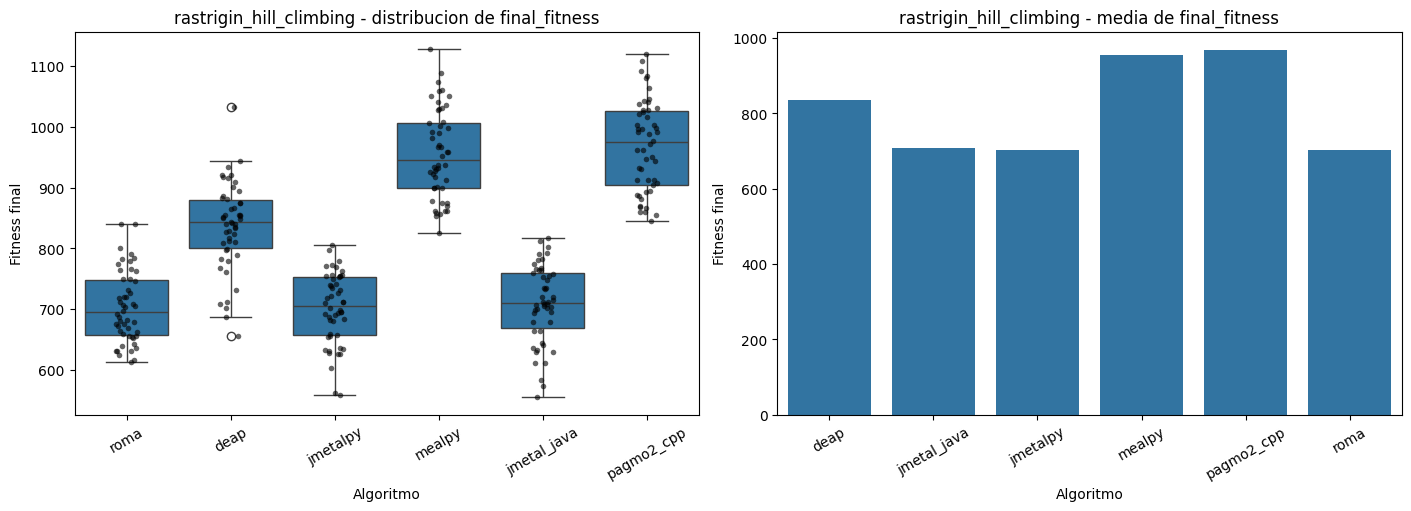

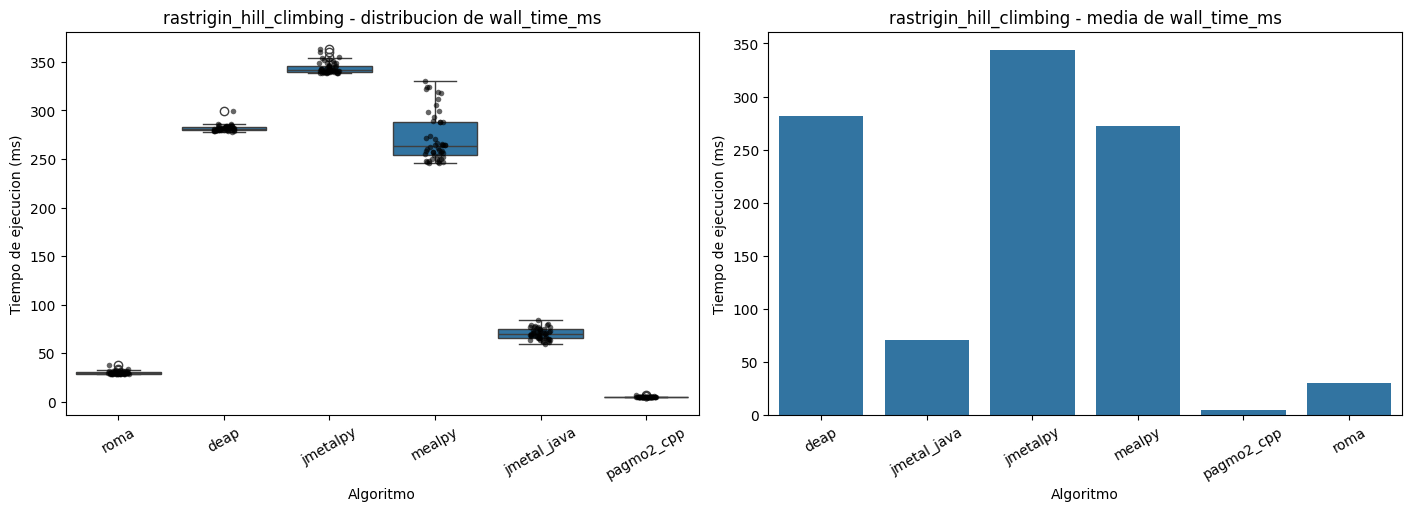

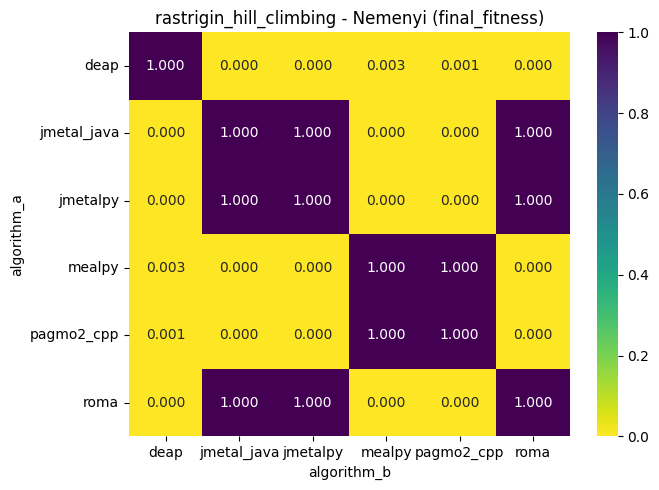

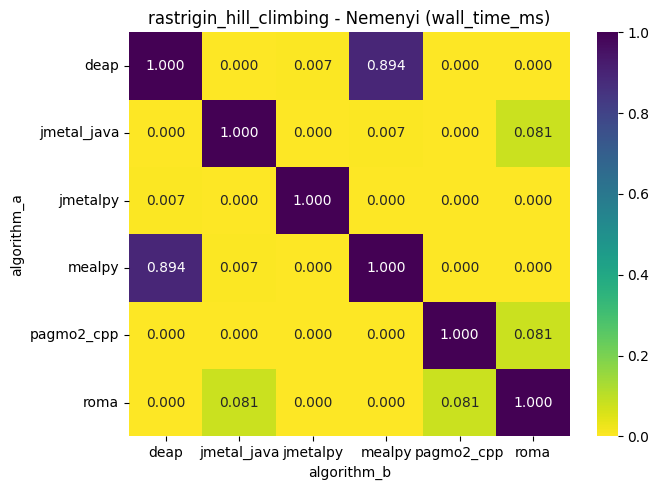

In [8]:
def plot_metric_distributions(problem_df: pd.DataFrame, benchmark_id: str, metric: str, ylabel: str):
    if plt is None:
        display(Markdown('`matplotlib` no esta disponible; no se pueden dibujar graficos.'))
        return

    plot_df = problem_df[(problem_df['status'] == 'ok') & problem_df[metric].notna()].copy()
    if plot_df.empty:
        display(Markdown(f'Sin datos para graficar `{metric}` en `{benchmark_id}`.'))
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    if sns is not None:
        sns.boxplot(data=plot_df, x='algorithm', y=metric, ax=axes[0])
        sns.stripplot(data=plot_df, x='algorithm', y=metric, ax=axes[0], color='black', alpha=0.6, size=4)
        summary = plot_df.groupby('algorithm')[metric].mean().reset_index()
        sns.barplot(data=summary, x='algorithm', y=metric, ax=axes[1])
    else:
        plot_df.boxplot(column=metric, by='algorithm', ax=axes[0])
        summary = plot_df.groupby('algorithm')[metric].mean()
        summary.plot(kind='bar', ax=axes[1])

    axes[0].set_title(f'{benchmark_id} - distribucion de {metric}')
    axes[0].set_xlabel('Algoritmo')
    axes[0].set_ylabel(ylabel)
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].set_title(f'{benchmark_id} - media de {metric}')
    axes[1].set_xlabel('Algoritmo')
    axes[1].set_ylabel(ylabel)
    axes[1].tick_params(axis='x', rotation=30)

    plt.show()


def plot_nemenyi_heatmap(result: dict, benchmark_id: str, metric: str):
    if plt is None or sns is None:
        return
    if result['nemenyi'].empty:
        return

    matrix = result['nemenyi'].pivot(index='algorithm_a', columns='algorithm_b', values='adjusted_p_value')
    plt.figure(figsize=(7, 5))
    sns.heatmap(matrix, annot=True, cmap='viridis_r', vmin=0.0, vmax=1.0, fmt='.3f')
    plt.title(f'{benchmark_id} - Nemenyi ({metric})')
    plt.tight_layout()
    plt.show()


if not analysis:
    display(Markdown('No hay datos cargados para generar graficos.'))
else:
    for benchmark_id, problem_df in runs_df.groupby('benchmark_id', sort=True):
        display(Markdown(f'## Graficos: {benchmark_id}'))
        plot_metric_distributions(problem_df, benchmark_id, 'final_fitness', 'Fitness final')
        plot_metric_distributions(problem_df, benchmark_id, 'wall_time_ms', 'Tiempo de ejecucion (ms)')
        plot_nemenyi_heatmap(analysis[benchmark_id]['fitness_test'], benchmark_id, 'final_fitness')
        plot_nemenyi_heatmap(analysis[benchmark_id]['wall_time_test'], benchmark_id, 'wall_time_ms')